In [1]:
!pip install tabpfn shap openpyxl -q

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from tabpfn import TabPFNClassifier
import torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.5 MB/s eta 0:00:00


In [2]:
# %% Cell 1 -- load both files and merge the Ambiguous flag onto the feature data
train_df = pd.read_csv("/content/GSE98320.csv")
uncertainty_df = pd.read_csv("/content/tabpfn_uncertainty_results.csv")

X_full = train_df.drop(columns=["sample_id", "diagnosis"])
y_full = train_df["diagnosis"]
sample_ids = train_df["sample_id"]

imputer = SimpleImputer(strategy="median")
X_full_imp = pd.DataFrame(imputer.fit_transform(X_full), columns=X_full.columns, index=X_full.index)

class_labels = sorted(y_full.unique())
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

merged = train_df[["sample_id"]].merge(uncertainty_df, on="sample_id", how="left")
assert merged["Ambiguous"].isna().sum() == 0, "Some samples couldn't be matched by sample_id -- check both files came from the same run"

ambiguous_mask = (merged["Ambiguous"] == "Ambiguous").values
print(f"Ambiguous samples: {ambiguous_mask.sum()} / {len(merged)}")

Using device: cuda
Ambiguous samples: 49 / 1181


In [3]:
import os
os.environ["TABPFN_TOKEN"]="tabpfn_sk_rikp7fixLNN9ZSniOTsSUbUyA2-jKHshJExcCxll0uo"

In [4]:
# %% Cell 2 -- fit ONE final TabPFN model on the full training set
# Note: the OOF predictions/flags came from 10 different fold-specific models
# during cross-validation. Here we fit a single model on all training data,
# which explains "how the final/deployed model behaves" rather than
# reproducing the exact fold-specific model behind each OOF prediction.
# This is the standard, tractable approach for post-hoc explanation.
final_model = TabPFNClassifier(device=device, random_state=42)
final_model.fit(X_full_imp, y_full)

def predict_proba_ordered(X):
    """Wrapper ensuring SHAP always sees probability columns in class_labels order."""
    X_df = pd.DataFrame(X, columns=X_full_imp.columns)
    proba = final_model.predict_proba(X_df)
    model_classes = list(final_model.classes_)
    out = np.zeros((X_df.shape[0], len(class_labels)))
    for i, cls in enumerate(class_labels):
        out[:, i] = proba[:, model_classes.index(cls)]
    return out

tabpfn-v3-classifier-v3_default.ckpt: reconstructing file:   0%|          |  0.00B /  213MB            

tabpfn-v3-classifier-v3_default.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

In [5]:
# %% Cell 3 -- build a small, representative SHAP background
# TabPFN is not a tree model, so we need a model-agnostic explainer, which
# means every background point costs a real forward pass through the model.
# shap.kmeans summarizes the background into k representative points instead
# of using hundreds of raw rows -- essential to keep this tractable.
background = shap.kmeans(X_full_imp, 30)
explainer = shap.KernelExplainer(predict_proba_ordered, background)

In [6]:
# %% Cell 4 -- run SHAP on just the ambiguous samples
X_ambiguous = X_full_imp[ambiguous_mask].reset_index(drop=True)
ids_ambiguous = sample_ids[ambiguous_mask].reset_index(drop=True)
meta_ambiguous = merged[ambiguous_mask].reset_index(drop=True)

print(f"Running SHAP on {len(X_ambiguous)} ambiguous samples -- this will take a while "
      f"(each sample requires many model forward passes; expect minutes, not seconds, per sample)")

raw_shap_output = explainer.shap_values(X_ambiguous, nsamples=250, l1_reg="num_features(30)")

# Normalize to a consistent shape regardless of SHAP version:
# target shape -> (n_samples, n_features, n_classes)
if isinstance(raw_shap_output, list):
    # older SHAP: list of (n_samples, n_features) arrays, one per class
    shap_values = np.stack(raw_shap_output, axis=-1)
else:
    # newer SHAP: already (n_samples, n_features, n_classes)
    shap_values = raw_shap_output

print("SHAP values shape:", shap_values.shape)
assert shap_values.shape == (len(X_ambiguous), X_full_imp.shape[1], len(class_labels)), \
    "Unexpected SHAP output shape -- inspect raw_shap_output before proceeding"

Running SHAP on 49 ambiguous samples -- this will take a while (each sample requires many model forward passes; expect minutes, not seconds, per sample)


  0%|          | 0/49 [00:00<?, ?it/s]

SHAP values shape: (49, 767, 3)


In [7]:
# %% Cell 5 -- per-sample explanation: top genes for predicted class + runner-up class
gene_names = X_full_imp.columns.tolist()
per_sample_rows = []

for i in range(len(X_ambiguous)):
    row_meta = meta_ambiguous.iloc[i]
    predicted_class = row_meta["y_pred"]
    proba_cols = {cls: row_meta[f"P_{cls}"] for cls in class_labels}
    sorted_classes = sorted(proba_cols, key=proba_cols.get, reverse=True)
    runner_up_class = sorted_classes[1]  # second-highest probability class

    pred_idx = class_labels.index(predicted_class)
    runner_idx = class_labels.index(runner_up_class)

    pred_shap = shap_values[i, :, pred_idx]
    runner_shap = shap_values[i, :, runner_idx]

    top_pred_genes = pd.Series(pred_shap, index=gene_names).sort_values(ascending=False).head(15)
    top_runner_genes = pd.Series(runner_shap, index=gene_names).sort_values(ascending=False).head(15)

    per_sample_rows.append({
        "sample_id": ids_ambiguous.iloc[i],
        "predicted_class": predicted_class,
        "runner_up_class": runner_up_class,
        "top_genes_for_predicted_class": ", ".join(
            f"{g}({v:.3f})" for g, v in top_pred_genes.items()
        ),
        "top_genes_for_runner_up_class": ", ".join(
            f"{g}({v:.3f})" for g, v in top_runner_genes.items()
        ),
    })

per_sample_df = pd.DataFrame(per_sample_rows)
per_sample_df.to_csv("/content/shap_per_sample_ambiguous.csv", index=False)
print("Saved: /content/shap_per_sample_ambiguous.csv")


Saved: /content/shap_per_sample_ambiguous.csv


In [9]:
# %% Cell 6 -- aggregate step: which genes most consistently drive ambiguity
# For each sample, we only look at its own predicted-vs-runner-up tension
# (different samples may have different class pairs in tension), then average
# the absolute contribution per gene across all ambiguous samples.
per_gene_contributions = np.zeros((len(X_ambiguous), len(gene_names)))

for i in range(len(X_ambiguous)):
    row_meta = meta_ambiguous.iloc[i]
    predicted_class = row_meta["y_pred"]
    proba_cols = {cls: row_meta[f"P_{cls}"] for cls in class_labels}
    sorted_classes = sorted(proba_cols, key=proba_cols.get, reverse=True)
    runner_up_class = sorted_classes[1]

    pred_idx = class_labels.index(predicted_class)
    runner_idx = class_labels.index(runner_up_class)

    # combined "tension" signal: how much each gene pushed the predicted class
    # up AND/OR pushed the runner-up class up -- both matter for ambiguity
    per_gene_contributions[i] = np.abs(shap_values[i, :, pred_idx]) + np.abs(shap_values[i, :, runner_idx])

aggregate_ambiguity_scores = pd.Series(
    per_gene_contributions.mean(axis=0), index=gene_names
).sort_values(ascending=False)

aggregate_df = aggregate_ambiguity_scores.reset_index()
aggregate_df.columns = ["gene_entrez_id", "mean_abs_shap_ambiguity_score"]
aggregate_df.to_csv("/content/shap_aggregate_ambiguity_ranking.csv", index=False)
print("Saved: /content/shap_aggregate_ambiguity_ranking.csv")
print("\nTop 20 genes most responsible for ambiguity across all flagged samples:")
print(aggregate_df.head(20).to_string(index=False))

Saved: /content/shap_aggregate_ambiguity_ranking.csv

Top 20 genes most responsible for ambiguity across all flagged samples:
gene_entrez_id  mean_abs_shap_ambiguity_score
         51365                       0.023252
         57823                       0.014619
          3824                       0.010660
          7851                       0.010238
        117157                       0.008657
          3958                       0.008470
          5450                       0.008454
         10578                       0.007844
           684                       0.007742
          6389                       0.007395
          3560                       0.007394
          9104                       0.007367
          4214                       0.007351
          3821                       0.007216
          4818                       0.007114
         83888                       0.006921
          2357                       0.006581
          2826                       0.006535


In [10]:
# %% Cell 6b -- translate Entrez IDs to gene symbols using your own B-HOT+ mapping file
bhot_mapping_raw = pd.read_csv("/content/BHOT_plus_entrez_mapping.csv")

# Reparse if it's still in the packed "original;symbol;entrez" single-column format
if bhot_mapping_raw.shape[1] == 1:
    split_cols = bhot_mapping_raw.iloc[:, 0].str.split(";")
    bhot_mapping = pd.DataFrame({
        "original_name": split_cols.str[0],
        "gene_symbol": split_cols.str[1],
        "entrez_id": split_cols.str[2],
    })
else:
    bhot_mapping = bhot_mapping_raw

bhot_mapping["entrez_id"] = bhot_mapping["entrez_id"].astype(str)
aggregate_df["gene_entrez_id"] = aggregate_df["gene_entrez_id"].astype(str)

aggregate_named = aggregate_df.merge(
    bhot_mapping[["entrez_id", "gene_symbol"]],
    left_on="gene_entrez_id", right_on="entrez_id", how="left"
).drop(columns=["entrez_id"])

# Flag anything that failed to match, rather than silently showing blank symbols
unmatched = aggregate_named["gene_symbol"].isna().sum()
if unmatched > 0:
    print(f"Warning: {unmatched} gene(s) had no matching symbol in the mapping file -- check these manually")

aggregate_named = aggregate_named[["gene_entrez_id", "gene_symbol", "mean_abs_shap_ambiguity_score"]]
aggregate_named.to_csv("/content/shap_aggregate_ambiguity_ranking_named.csv", index=False)

print("Top 20 genes most responsible for ambiguity (with symbols):")
print(aggregate_named.head(20).to_string(index=False))

Top 20 genes most responsible for ambiguity (with symbols):
gene_entrez_id gene_symbol  mean_abs_shap_ambiguity_score
         51365       PLA1A                       0.023252
         57823      SLAMF7                       0.014619
          3824       KLRD1                       0.010660
          7851        MALL                       0.010238
        117157      SH2D1B                       0.008657
          3958      LGALS3                       0.008470
          5450     POU2AF1                       0.008454
         10578        GNLY                       0.007844
           684        BST2                       0.007742
          6389        SDHA                       0.007395
          3560       IL2RB                       0.007394
          9104         RGN                       0.007367
          4214      MAP3K1                       0.007351
          3821       KLRC1                       0.007216
          4818        NKG7                       0.007114
         838

In [11]:
# %% Cell 7 -- check the paper's own 6 added genes against the ambiguity ranking
paper_added_genes = ["CST7", "KLRC4-KLRK1", "TRBC1", "TRBV6-5", "TRBV19", "ZFX"]

paper_genes_in_ranking = aggregate_named[aggregate_named["gene_symbol"].isin(paper_added_genes)]

print("Where do the paper's 6 added genes rank in the ambiguity list?")
if len(paper_genes_in_ranking) > 0:
    # Show their rank position too, not just their score
    aggregate_named_ranked = aggregate_named.reset_index(drop=True)
    aggregate_named_ranked["rank"] = aggregate_named_ranked.index + 1
    matches = aggregate_named_ranked[aggregate_named_ranked["gene_symbol"].isin(paper_added_genes)]
    print(matches[["rank", "gene_symbol", "mean_abs_shap_ambiguity_score"]].to_string(index=False))
else:
    print("None of the paper's 6 added genes appear in the B-HOT+ feature set used here, "
          "or none scored high enough to be worth flagging -- checking full length of ranking:")
    print(f"(Ranking list has {len(aggregate_named)} genes total)")

Where do the paper's 6 added genes rank in the ambiguity list?
 rank gene_symbol  mean_abs_shap_ambiguity_score
  274     TRBV6-5                       0.002054
  294 KLRC4-KLRK1                       0.001955
  352      TRBV19                       0.001665
  354       TRBC1                       0.001661
  446        CST7                       0.001214
  682         ZFX                       0.000149


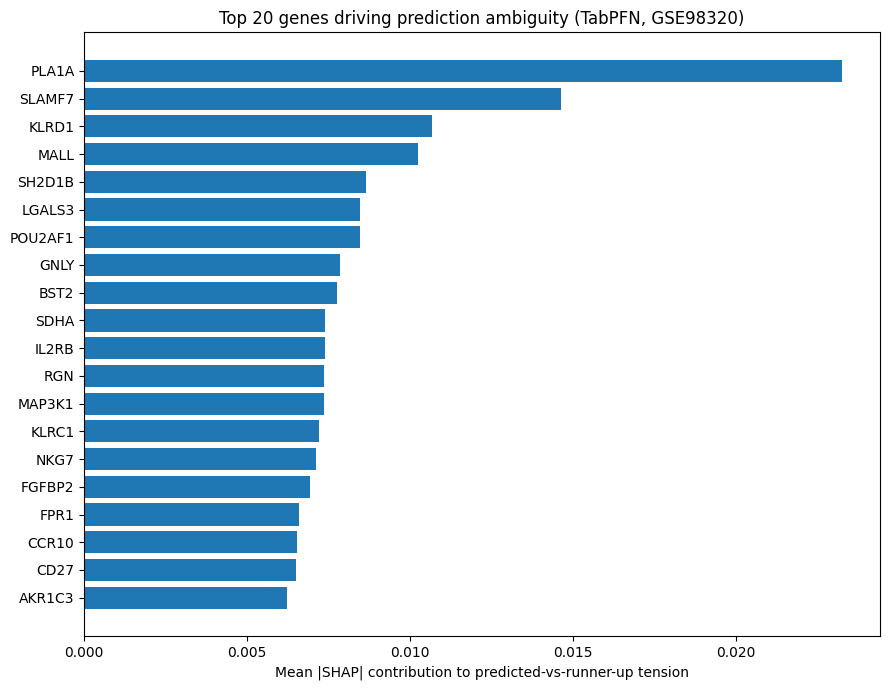

In [12]:
# %% Cell 8 -- plot: top ambiguity-driving genes (using symbols, not Entrez IDs)
top_n = 20
top_genes_plot = aggregate_named.head(top_n).iloc[::-1]  # reverse for horizontal bar order

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_genes_plot["gene_symbol"], top_genes_plot["mean_abs_shap_ambiguity_score"])
ax.set_xlabel("Mean |SHAP| contribution to predicted-vs-runner-up tension")
ax.set_title(f"Top {top_n} genes driving prediction ambiguity (TabPFN, GSE98320)")
plt.tight_layout()
plt.savefig("/content/shap_ambiguity_top_genes.png", dpi=150)
plt.show()

In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive"))
os.listdir("/content/drive/MyDrive") if os.path.exists("/content/drive/MyDrive") else "NOT MOUNTED"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive"))

True


In [13]:
# %% Cell 9 -- comparison: full non-ambiguous set (all 1,132 samples), checkpointed to Drive
import os

# Make sure Drive is mounted first (the interactive Mount Drive button in the
# file sidebar, not a code-based mount) before running this cell.
CHECKPOINT_PATH = "/content/shap_nonambig_checkpoint.npy"
BATCH_SIZE = 50

non_ambiguous_idx = np.where(~ambiguous_mask)[0]
SAMPLE_SIZE = len(non_ambiguous_idx)  # all non-ambiguous samples, no subsampling

X_nonambig_sample = X_full_imp.iloc[non_ambiguous_idx].reset_index(drop=True)
meta_nonambig_sample = merged.iloc[non_ambiguous_idx].reset_index(drop=True)

print(f"Running SHAP on all {SAMPLE_SIZE} non-ambiguous samples "
      f"in batches of {BATCH_SIZE}, checkpointing to Drive.")
print("If this session disconnects, just remount Drive and rerun this exact cell -- "
      "it will resume from the last completed batch instead of starting over.")

if os.path.exists(CHECKPOINT_PATH):
    saved = np.load(CHECKPOINT_PATH, allow_pickle=True).item()
    shap_values_nonambig_list = saved["shap_values"]
    start_idx = saved["completed"]
    print(f"Resuming from checkpoint: {start_idx}/{SAMPLE_SIZE} already done")
else:
    shap_values_nonambig_list = [None] * SAMPLE_SIZE
    start_idx = 0

for batch_start in range(start_idx, SAMPLE_SIZE, BATCH_SIZE):
    batch_end = min(batch_start + BATCH_SIZE, SAMPLE_SIZE)
    batch_X = X_nonambig_sample.iloc[batch_start:batch_end]

    raw_batch = explainer.shap_values(batch_X, nsamples=250, l1_reg="num_features(30)")
    batch_shap = np.stack(raw_batch, axis=-1) if isinstance(raw_batch, list) else raw_batch

    for j, idx in enumerate(range(batch_start, batch_end)):
        shap_values_nonambig_list[idx] = batch_shap[j]

    np.save(CHECKPOINT_PATH, {"shap_values": shap_values_nonambig_list, "completed": batch_end})
    print(f"  Checkpoint saved to Drive: {batch_end}/{SAMPLE_SIZE} done "
          f"({100 * batch_end / SAMPLE_SIZE:.1f}%)")

shap_values_nonambig = np.stack(shap_values_nonambig_list, axis=0)
print("\nFinal SHAP values shape:", shap_values_nonambig.shape)

# %% Cell 9b -- aggregate the non-ambiguous scores and compare against the ambiguous ranking
per_gene_contrib_nonambig = np.zeros((SAMPLE_SIZE, len(gene_names)))

for i in range(SAMPLE_SIZE):
    row_meta = meta_nonambig_sample.iloc[i]
    predicted_class = row_meta["y_pred"]
    proba_cols = {cls: row_meta[f"P_{cls}"] for cls in class_labels}
    sorted_classes = sorted(proba_cols, key=proba_cols.get, reverse=True)
    runner_up_class = sorted_classes[1]
    pred_idx = class_labels.index(predicted_class)
    runner_idx = class_labels.index(runner_up_class)
    per_gene_contrib_nonambig[i] = (
        np.abs(shap_values_nonambig[i, :, pred_idx]) + np.abs(shap_values_nonambig[i, :, runner_idx])
    )

aggregate_nonambig = pd.Series(
    per_gene_contrib_nonambig.mean(axis=0), index=gene_names
).sort_values(ascending=False)

comparison_df = pd.DataFrame({
    "ambiguous_rank_score": aggregate_ambiguity_scores,
    "nonambiguous_rank_score": aggregate_nonambig,
})
comparison_df.index.name = "gene_entrez_id"
comparison_df = comparison_df.reset_index()
comparison_df["gene_entrez_id"] = comparison_df["gene_entrez_id"].astype(str)

# Reuses bhot_mapping loaded earlier in Cell 6b -- rerun that cell first if your
# session restarted since then
comparison_df = comparison_df.merge(
    bhot_mapping[["entrez_id", "gene_symbol"]],
    left_on="gene_entrez_id", right_on="entrez_id", how="left"
).drop(columns=["entrez_id"])

comparison_df["ambiguity_specific"] = (
    comparison_df["ambiguous_rank_score"] - comparison_df["nonambiguous_rank_score"]
)
comparison_df = comparison_df.sort_values("ambiguous_rank_score", ascending=False)
comparison_df.to_csv("/content/shap_ambiguous_vs_nonambiguous_comparison.csv", index=False)

print("\nSaved: /content/shap_ambiguous_vs_nonambiguous_comparison.csv")
print("\nTop 15 genes MORE responsible for ambiguity than for confident predictions:")
print(comparison_df.sort_values("ambiguity_specific", ascending=False)
      [["gene_symbol", "ambiguous_rank_score", "nonambiguous_rank_score", "ambiguity_specific"]]
      .head(15).to_string(index=False))

Running SHAP on all 1132 non-ambiguous samples in batches of 50, checkpointing to Drive.
If this session disconnects, just remount Drive and rerun this exact cell -- it will resume from the last completed batch instead of starting over.
Resuming from checkpoint: 900/1132 already done


  0%|          | 0/50 [00:00<?, ?it/s]

  Checkpoint saved to Drive: 950/1132 done (83.9%)


  0%|          | 0/50 [00:00<?, ?it/s]

  Checkpoint saved to Drive: 1000/1132 done (88.3%)


...

  Checkpoint saved to Drive: 1050/1132 done (92.8%)


  0%|          | 0/50 [00:00<?, ?it/s]

  Checkpoint saved to Drive: 1100/1132 done (97.2%)


  0%|          | 0/32 [00:00<?, ?it/s]

  Checkpoint saved to Drive: 1132/1132 done (100.0%)

Final SHAP values shape: (1132, 767, 3)

Saved: /content/shap_ambiguous_vs_nonambiguous_comparison.csv

Top 15 genes MORE responsible for ambiguity than for confident predictions:
gene_symbol  ambiguous_rank_score  nonambiguous_rank_score  ambiguity_specific
     SLAMF7              0.014619                 0.001234            0.013386
     LGALS3              0.008470                 0.000709            0.007761
    POU2AF1              0.008454                 0.001151            0.007302
       SDHA              0.007395                 0.000793            0.006603
       BST2              0.007742                 0.001402            0.006340
        RGN              0.007367                 0.001213            0.006154
     MAP3K1              0.007351                 0.001597            0.005754
       CD27              0.006493                 0.000790            0.005703
       FPR1              0.006581                 0.000

In [ ]:
import numpy as np
saved = np.load("/content/drive/MyDrive/shap_nonambig_checkpoint.npy", allow_pickle=True).item()
print("Completed:", saved["completed"])

Completed: 900


In [ ]:
# %% Cell -- save all output files to Drive (primary) + attempt browser download (bonus)
import os
import shutil
import glob

DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/bhot_shap_outputs"
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

# Grab every result file this project has produced so far in /content
patterns = ["*.csv", "*.xlsx", "*.png", "*.npy"]
files_to_save = []
for pattern in patterns:
    files_to_save.extend(glob.glob(f"/content/{pattern}"))

print(f"Found {len(files_to_save)} files to copy to Drive:")
for f in files_to_save:
    print(" -", f)

for f in files_to_save:
    dest = os.path.join(DRIVE_OUTPUT_DIR, os.path.basename(f))
    shutil.copy(f, dest)

print(f"\nAll files copied to: {DRIVE_OUTPUT_DIR}")
print("These are now safe in Drive even if this Colab session disconnects or times out.")

# Bonus: also try triggering a direct browser download, in case you're still around
try:
    from google.colab import files
    zip_path = "/content/all_shap_outputs.zip"
    shutil.make_archive("/content/all_shap_outputs", "zip", root_dir="/content", base_dir=".",
                         # only include the files we already identified, not everything in /content
                         )
    # Simpler and safer: zip just the identified files, not the whole /content dir
    import zipfile
    with zipfile.ZipFile(zip_path, "w") as zf:
        for f in files_to_save:
            zf.write(f, arcname=os.path.basename(f))
    files.download(zip_path)
    print("Also triggered a browser download of all_shap_outputs.zip")
except Exception as e:
    print(f"Browser download skipped/failed ({e}) -- not a problem, Drive copy above is what matters.")

Found 9 files to copy to Drive:
 - /content/shap_ambiguous_vs_nonambiguous_comparison.csv
 - /content/tabpfn_uncertainty_results.csv
 - /content/shap_per_sample_ambiguous.csv
 - /content/GSE98320.csv
 - /content/shap_aggregate_ambiguity_ranking_named.csv
 - /content/BHOT_plus_entrez_mapping.csv
 - /content/shap_aggregate_ambiguity_ranking.csv
 - /content/shap_ambiguity_top_genes.png
 - /content/shap_nonambig_checkpoint.npy

All files copied to: /content/drive/MyDrive/bhot_shap_outputs
These are now safe in Drive even if this Colab session disconnects or times out.
